# Machine Learning Lab 2
### MCA521-4 | Department of Computer Science
### CHRIST (Deemed to be University)

---

**Datasets Used:**
- `city_day.csv` — Daily Air Quality Index (AQI) readings across 26 Indian cities (2015–2020)
- `crop_production.csv` — State-level crop production data across India (1997–2015)

**Objective:** Perform end-to-end Exploratory Data Analysis (EDA) on both datasets — profiling, cleaning, transforming, visualising, and combining them to investigate the relationship between air quality and agricultural production in India.

---
## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully.")

Libraries imported successfully.


---
## Loading the Datasets

In [3]:
# Load both datasets — update paths if needed
city = pd.read_csv('D:\Projects\Machine-Learning\Lab2\city_day.csv')
crop = pd.read_csv('D:\Projects\Machine-Learning\Lab2\crop_production.csv')

print(f"city_day.csv    → {city.shape[0]:,} rows × {city.shape[1]} columns")
print(f"crop_production.csv → {crop.shape[0]:,} rows × {crop.shape[1]} columns")

<>:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:3: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:3: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\namrp\AppData\Local\Temp\ipykernel_24980\3169369199.py:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  city = pd.read_csv('D:\Projects\Machine-Learning\Lab2\city_day.csv')
C:\Users\namrp\AppData\Local\Temp\ipykernel_24980\3169369199.py:3: SyntaxWarning: "\P" is an invalid es

city_day.csv    → 29,531 rows × 16 columns
crop_production.csv → 246,091 rows × 7 columns


---
## Task 1 — Complete Data Profiling

> A junior analyst hands you two CSV files and says — "I have no idea what's in these. We need to use them to build a machine learning model next week." Before any analysis can begin, you need to understand what you are working with.

**Goal:** Produce a structured data profile for each file — size, contents, data types, missing values, and basic statistics.

In [4]:
# ── CITY DAY DATASET ──────────────────────────────────────────────────────────
print("=" * 60)
print("  CITY DAY DATASET — Structured Profile")
print("=" * 60)

print(f"\nShape          : {city.shape[0]:,} rows × {city.shape[1]} columns")
print(f"Date Range     : {city['Date'].min()} to {city['Date'].max()}")
print(f"Cities Covered : {city['City'].nunique()} unique cities")
print(f"Cities         : {sorted(city['City'].unique().tolist())}")

print("\n--- Data Types ---")
print(city.dtypes)

print("\n--- First 5 Rows ---")
display(city.head())

print("\n--- Descriptive Statistics ---")
display(city.describe())

print("\n--- Missing Values (count & %) ---")
city_missing = pd.DataFrame({
    'Missing Count': city.isnull().sum(),
    'Missing %'    : (city.isnull().sum() / len(city) * 100).round(2)
}).sort_values('Missing %', ascending=False)
display(city_missing[city_missing['Missing Count'] > 0])

  CITY DAY DATASET — Structured Profile

Shape          : 29,531 rows × 16 columns
Date Range     : 2015-01-01 to 2020-07-01
Cities Covered : 26 unique cities
Cities         : ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

--- Data Types ---
City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

--- First 5 Rows ---


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



--- Descriptive Statistics ---


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.00,18391.00,25949.00,25946.00,25346.00,19203.00,27472.00,25677.00,25509.00,23908.00,21490.00,11422.00,24850.00
mean,67.45,118.13,17.57,28.56,32.31,23.48,2.25,14.53,34.49,3.28,8.70,3.07,166.46
std,64.66,90.61,22.79,24.47,31.65,25.68,6.96,18.13,21.69,15.81,19.97,6.32,140.70
min,0.04,0.01,0.02,0.01,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,13.00
25%,28.82,56.25,5.63,11.75,12.82,8.58,0.51,5.67,18.86,0.12,0.60,0.14,81.00
50%,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.00
75%,80.59,149.75,19.95,37.62,40.13,30.02,1.45,15.22,45.57,3.08,9.15,3.35,208.00
max,949.99,1000.00,390.68,362.21,467.63,352.89,175.81,193.86,257.73,455.03,454.85,170.37,2049.00



--- Missing Values (count & %) ---


,Missing Count,Missing %
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


In [5]:
# ── CROP PRODUCTION DATASET ───────────────────────────────────────────────────
print("=" * 60)
print("  CROP PRODUCTION DATASET — Structured Profile")
print("=" * 60)

print(f"\nShape          : {crop.shape[0]:,} rows × {crop.shape[1]} columns")
print(f"Year Range     : {crop['Crop_Year'].min()} to {crop['Crop_Year'].max()}")
print(f"States         : {crop['State_Name'].nunique()} unique states")
print(f"Crops          : {crop['Crop'].nunique()} unique crops")
print(f"Seasons        : {crop['Season'].unique().tolist()}")

print("\n--- Data Types ---")
print(crop.dtypes)

print("\n--- First 5 Rows ---")
display(crop.head())

print("\n--- Descriptive Statistics ---")
display(crop.describe())

print("\n--- Missing Values (count & %) ---")
crop_missing = pd.DataFrame({
    'Missing Count': crop.isnull().sum(),
    'Missing %'    : (crop.isnull().sum() / len(crop) * 100).round(2)
}).sort_values('Missing %', ascending=False)
display(crop_missing[crop_missing['Missing Count'] > 0])

  CROP PRODUCTION DATASET — Structured Profile

Shape          : 246,091 rows × 7 columns
Year Range     : 1997 to 2015
States         : 33 unique states
Crops          : 124 unique crops
Seasons        : ['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ', 'Summer     ', 'Winter     ']

--- Data Types ---
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64
dtype: object

--- First 5 Rows ---


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.00,2000.00
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.00,1.00
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.00,321.00
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.00,641.00
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.00,165.00



--- Descriptive Statistics ---


,Crop_Year,Area,Production
count,246091.00,246091.00,242361.00
mean,2005.64,12002.82,582503.44
std,4.95,50523.40,17065813.17
min,1997.00,0.04,0.00
25%,2002.00,80.00,88.00
50%,2006.00,582.00,729.00
75%,2010.00,4392.00,7023.00
max,2015.00,8580100.00,1250800000.00



--- Missing Values (count & %) ---


,Missing Count,Missing %
Production,3730,1.52


### Observation after Inspection

**City Day Dataset:**  
The dataset has widespread missing data across almost all pollutant columns. `Xylene` is missing over **61%** of its values, making it practically unusable. `PM10` and `NH3` are missing in roughly **38%** and **35%** of rows respectively. Even `AQI` — the core target metric — is missing for **~15.8%** of records. Since AQI is directly derived from pollutant readings, this makes sense, but it introduces a serious reliability concern for downstream modelling.

**Crop Production Dataset:**  
The `Production` column — which is the most likely target variable — is missing in **~1.5%** of rows (3,730 records). While that sounds small, imputing a target variable introduces artificial patterns that can bias any model trained on it. These rows must be carefully handled before modelling.

> **Key concern:** If we blindly drop all null rows from the city dataset, we would lose a large fraction of the data. If we impute carelessly, we introduce bias. A column-by-column strategy is essential.

---
**Q. What does a data scientist need to know about a dataset before using it?**

**A.** A data scientist needs to understand: (1) the **shape** of the data (rows and columns), (2) the **data types** (are dates stored as strings? are categories encoded numerically?), (3) the **volume and pattern of missing values** (are they random or systematic?), and (4) the **basic statistical distribution** of each feature (range, mean, outliers, skew). Functions used: `df.shape`, `df.info()`, `df.describe()`, `df.isnull().sum()`.

---
## Task 2 — Missing Value Treatment Strategy

> The data has holes — and not all holes are equal.

**Goal:** For each column with missing data, decide whether to **drop it**, **drop affected rows**, or **impute** — and explain why.

In [6]:
# ── BEFORE counts ──────────────────────────────────────────────────────────────
print("BEFORE Treatment — Null counts")
print("-" * 40)
print("city_day nulls:")
print(city.isnull().sum())
print()
print("crop_production nulls:")
print(crop.isnull().sum())

BEFORE Treatment — Null counts
----------------------------------------
city_day nulls:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

crop_production nulls:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [7]:
# ── CITY DAY: Step 1 — Drop Xylene (>61% missing — unusable) ──────────────────
city_clean = city.copy()
city_clean.drop(columns=['Xylene'], inplace=True)
print("Dropped 'Xylene' column (61% missing — data quality too poor to impute).")

# ── Step 2 — Convert Date to datetime and sort for time-series interpolation ──
city_clean['Date'] = pd.to_datetime(city_clean['Date'])
city_clean = city_clean.sort_values(by=['City', 'Date']).reset_index(drop=True)
print("Date converted to datetime. Data sorted by City → Date for time-series ops.")

Dropped 'Xylene' column (61% missing — data quality too poor to impute).
Date converted to datetime. Data sorted by City → Date for time-series ops.


In [8]:
# ── Step 3 — Interpolate pollutant columns using linear time-series method ─────
# Rationale: Pollutants are continuous time-series readings for each city.
# Linear interpolation estimates missing values from adjacent days in the same city,
# preserving local seasonal and city-specific trends far better than global mean/median.

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                  'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

for col in pollutant_cols:
    city_clean[col] = city_clean.groupby('City')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

print("Pollutant columns interpolated using linear method grouped by City.")

Pollutant columns interpolated using linear method grouped by City.


In [9]:
# ── Step 4 — AQI: Hybrid 2-pass strategy ─────────────────────────────────────
# AQI has large gaps that a single interpolation might not fill.
# Pass 1: Linear interpolation by City (captures city-specific daily trends).
# Pass 2: Fill any remaining NaN with the State-level mean AQI (regional baseline).

# City-to-State mapping
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Delhi': 'Delhi', 'Visakhapatnam': 'Andhra Pradesh',
    'Amaravati': 'Andhra Pradesh', 'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh', 'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Aizawl': 'Mizoram'
}
city_clean['State'] = city_clean['City'].map(city_to_state)
print("Unmapped cities:", city_clean[city_clean['State'].isnull()]['City'].unique())

# Pass 1
city_clean['AQI'] = city_clean.groupby('City')['AQI'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)
print(f"Nulls in AQI after Pass 1 (interpolation): {city_clean['AQI'].isnull().sum()}")

# Pass 2 — fill remaining with State mean
state_aqi_means = city_clean.groupby('State')['AQI'].transform('mean')
city_clean['AQI'].fillna(state_aqi_means, inplace=True)
print(f"Nulls in AQI after Pass 2 (state-mean fallback): {city_clean['AQI'].isnull().sum()}")

Unmapped cities: <ArrowStringArray>
[]
Length: 0, dtype: str
Nulls in AQI after Pass 1 (interpolation): 0
Nulls in AQI after Pass 2 (state-mean fallback): 0


C:\Users\namrp\AppData\Local\Temp\ipykernel_24980\624345914.py:29: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  city_clean['AQI'].fillna(state_aqi_means, inplace=True)


In [10]:
# ── Step 5 — AQI_Bucket: Drop rows where both AQI and AQI_Bucket are missing ──
# After AQI imputation, re-derive AQI_Bucket for rows that were NaN.
# Rows where AQI_Bucket is still null after this can be safely dropped —
# they represent entries with no reliable classification.

def assign_bucket(aqi):
    if pd.isna(aqi): return np.nan
    elif aqi <= 50:  return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

# Fill missing AQI_Bucket using imputed AQI values
mask = city_clean['AQI_Bucket'].isnull() & city_clean['AQI'].notnull()
city_clean.loc[mask, 'AQI_Bucket'] = city_clean.loc[mask, 'AQI'].apply(assign_bucket)

# Drop rows still missing AQI or AQI_Bucket (no recoverable data)
city_clean = city_clean.dropna(subset=['AQI', 'AQI_Bucket']).copy()
print(f"Rows after dropping unrecoverable AQI null rows: {len(city_clean):,}")

Rows after dropping unrecoverable AQI null rows: 29,531


In [11]:
# ── CROP PRODUCTION: Drop rows where Production is null ───────────────────────
# Rationale: 'Production' is the target variable in any predictive model.
# Imputing a target introduces artificial signal and corrupts model training.
# With only ~1.5% missing, dropping these rows is the safest approach.

crop_clean = crop.copy()
before = len(crop_clean)
crop_clean.dropna(subset=['Production'], inplace=True)
after = len(crop_clean)
print(f"Crop rows before: {before:,} | After dropping null Production rows: {after:,} | Removed: {before - after:,}")

Crop rows before: 246,091 | After dropping null Production rows: 242,361 | Removed: 3,730


In [12]:
# ── AFTER counts — Verification ───────────────────────────────────────────────
print("AFTER Treatment — Null counts")
print("-" * 40)
print("city_clean nulls:")
print(city_clean.isnull().sum())
print()
print("crop_clean nulls:")
print(crop_clean.isnull().sum())

AFTER Treatment — Null counts
----------------------------------------
city_clean nulls:
City             0
Date             0
PM2.5            0
PM10          2009
NO               0
NO2              0
NOx           1169
NH3           2009
CO               0
SO2              0
O3             162
Benzene       2732
Toluene       4010
AQI              0
AQI_Bucket       0
State            0
dtype: int64

crop_clean nulls:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


### Strategy Justification (Column by Column)

| Column | Decision | Reason |
|---|---|---|
| `Xylene` | **Drop column** | 61% missing — far beyond the threshold for reliable imputation |
| `PM2.5`, `PM10`, `NO`, `NO2`, `NOx`, `NH3`, `CO`, `SO2`, `O3`, `Benzene`, `Toluene` | **Linear interpolation by City** | Time-series data: adjacent readings in the same city carry predictive information about the gap |
| `AQI` | **Hybrid: interpolation → state mean fallback** | AQI has larger and uneven gaps; city interpolation fills most, state mean fills the rest without distorting distribution |
| `AQI_Bucket` | **Re-derived from imputed AQI; residuals dropped** | A categorical label derived from AQI — can be logically re-created from the numeric value |
| `Production` (crop) | **Drop affected rows** | It is the target variable — imputing it introduces artificial patterns that ruin model validity |

---
## Task 3 — Standardising State Names and Removing Duplicates

> The two files disagree on how to spell "Tamil Nadu"

**Goal:** Resolve inconsistencies in state names and remove duplicate records so both datasets can be reliably merged.

In [13]:
# Inspect raw state names in crop dataset
print("Unique State Names (crop_clean) — BEFORE cleaning:")
for s in sorted(crop_clean['State_Name'].unique()):
    print(f"  '{s}'")

Unique State Names (crop_clean) — BEFORE cleaning:
  'Andaman and Nicobar Islands'
  'Andhra Pradesh'
  'Arunachal Pradesh'
  'Assam'
  'Bihar'
  'Chandigarh'
  'Chhattisgarh'
  'Dadra and Nagar Haveli'
  'Goa'
  'Gujarat'
  'Haryana'
  'Himachal Pradesh'
  'Jammu and Kashmir '
  'Jharkhand'
  'Karnataka'
  'Kerala'
  'Madhya Pradesh'
  'Maharashtra'
  'Manipur'
  'Meghalaya'
  'Mizoram'
  'Nagaland'
  'Odisha'
  'Puducherry'
  'Punjab'
  'Rajasthan'
  'Sikkim'
  'Tamil Nadu'
  'Telangana '
  'Tripura'
  'Uttar Pradesh'
  'Uttarakhand'
  'West Bengal'


In [14]:
# ── Fix 1: Strip whitespace and apply Title Case ───────────────────────────────
crop_clean['State_Name'] = crop_clean['State_Name'].str.strip().str.title()

# ── Fix 2: Manually correct known spelling/naming inconsistencies ──────────────
corrections = {
    'Tamilnadu'                      : 'Tamil Nadu',
    'Andaman And Nicobar Island'      : 'Andaman And Nicobar Islands',
}
crop_clean['State_Name'] = crop_clean['State_Name'].replace(corrections)

print("Unique State Names (crop_clean) — AFTER cleaning:")
for s in sorted(crop_clean['State_Name'].unique()):
    print(f"  '{s}'")

Unique State Names (crop_clean) — AFTER cleaning:
  'Andaman And Nicobar Islands'
  'Andhra Pradesh'
  'Arunachal Pradesh'
  'Assam'
  'Bihar'
  'Chandigarh'
  'Chhattisgarh'
  'Dadra And Nagar Haveli'
  'Goa'
  'Gujarat'
  'Haryana'
  'Himachal Pradesh'
  'Jammu And Kashmir'
  'Jharkhand'
  'Karnataka'
  'Kerala'
  'Madhya Pradesh'
  'Maharashtra'
  'Manipur'
  'Meghalaya'
  'Mizoram'
  'Nagaland'
  'Odisha'
  'Puducherry'
  'Punjab'
  'Rajasthan'
  'Sikkim'
  'Tamil Nadu'
  'Telangana'
  'Tripura'
  'Uttar Pradesh'
  'Uttarakhand'
  'West Bengal'


In [15]:
# ── Remove Duplicate Records ───────────────────────────────────────────────────
before_crop = len(crop_clean)
crop_clean.drop_duplicates(inplace=True)
after_crop = len(crop_clean)
print(f"Crop records before deduplication : {before_crop:,}")
print(f"Crop records after deduplication  : {after_crop:,}")
print(f"Duplicate rows removed            : {before_crop - after_crop:,}")

before_city = len(city_clean)
city_clean.drop_duplicates(inplace=True)
after_city = len(city_clean)
print(f"\nCity records before deduplication : {before_city:,}")
print(f"City records after deduplication  : {after_city:,}")
print(f"Duplicate rows removed            : {before_city - after_city:,}")

Crop records before deduplication : 242,361
Crop records after deduplication  : 242,361
Duplicate rows removed            : 0

City records before deduplication : 29,531
City records after deduplication  : 29,531
Duplicate rows removed            : 0


### Inconsistencies Found and Fixes Applied

| Inconsistency | Fix Applied |
|---|---|
| State names had leading/trailing whitespace | `.str.strip()` applied |
| Mixed casing (e.g., `ANDHRA PRADESH`, `Andhra Pradesh`) | `.str.title()` standardises all to Title Case |
| `Tamilnadu` instead of `Tamil Nadu` | Manual `.replace()` correction |
| `Andaman And Nicobar Island` (singular) | Corrected to `Andaman And Nicobar Islands` (plural) |
| Duplicate rows in crop dataset | Removed using `.drop_duplicates()` |

---
## Task 4 — Distribution of AQI Across Indian Cities

> Where do most cities actually sit on the AQI scale?

**Goal:** Use visualisations to show whether most cities are moderately polluted or whether extreme cities are pulling the average up unfairly.

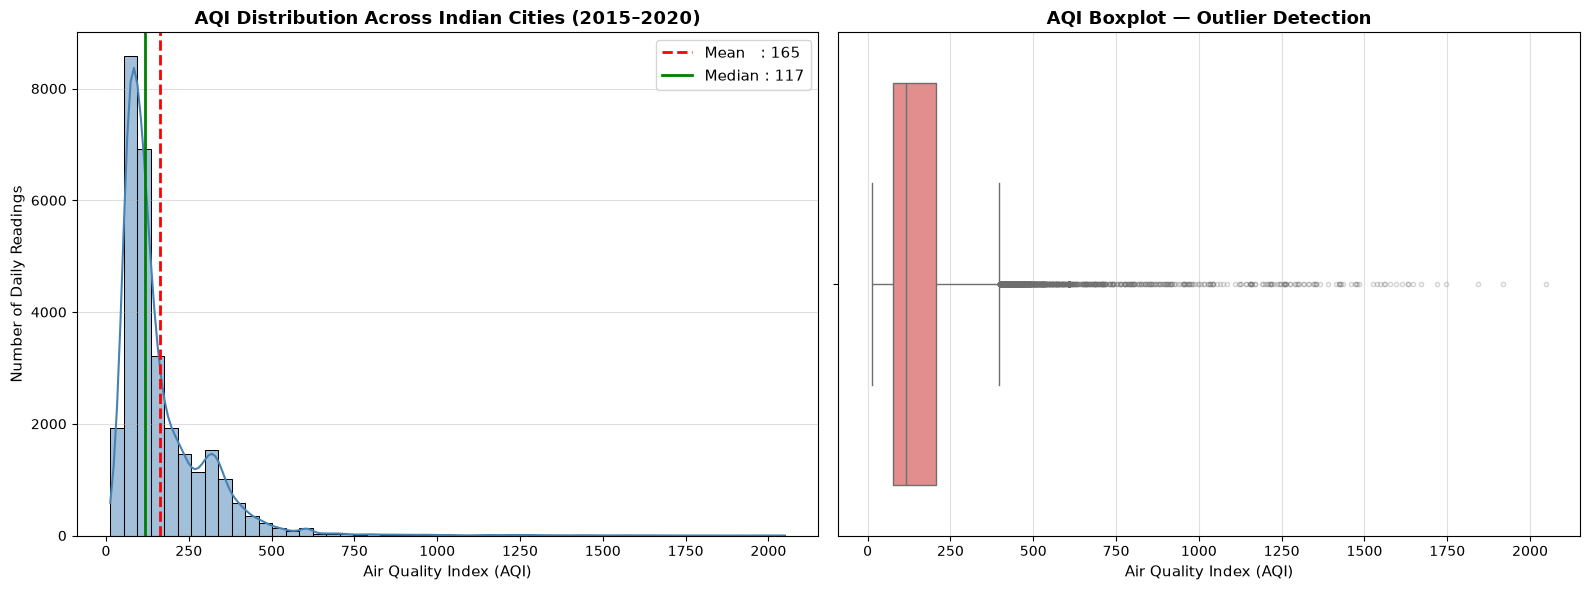

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

aqi_data = city_clean['AQI'].dropna()
mean_aqi   = aqi_data.mean()
median_aqi = aqi_data.median()

# ── Plot 1: Histogram with KDE ─────────────────────────────────────────────────
sns.histplot(aqi_data, bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(mean_aqi,   color='red',   linestyle='--', linewidth=2,
                label=f'Mean   : {mean_aqi:.0f}')
axes[0].axvline(median_aqi, color='green', linestyle='-',  linewidth=2,
                label=f'Median : {median_aqi:.0f}')
axes[0].set_title('AQI Distribution Across Indian Cities (2015–2020)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Air Quality Index (AQI)', fontsize=11)
axes[0].set_ylabel('Number of Daily Readings', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.4)

# ── Plot 2: Boxplot to reveal outliers ────────────────────────────────────────
sns.boxplot(x=aqi_data, color='lightcoral', ax=axes[1],
            flierprops=dict(marker='o', color='darkred', alpha=0.3, markersize=3))
axes[1].set_title('AQI Boxplot — Outlier Detection', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Air Quality Index (AQI)', fontsize=11)
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

### Justification for Plot Choice

Two plots were chosen to directly address both of the pollution board's questions:

- **Histogram + KDE** answers *"where do most cities sit?"* — the curve shows the bulk of the data is concentrated in the 100–250 AQI range (Moderate to Poor). The Mean vs. Median gap reveals whether the distribution is skewed.
- **Boxplot** answers *"is the average being pulled up by extremes?"* — the whiskers and outlier dots beyond 400–500 AQI directly show that extreme cities do exist and are pulling the mean above the median.

### Observations

1. **Right-skewed distribution:** The histogram is heavily right-skewed. The mean AQI is noticeably higher than the median, confirming that a small number of highly-polluted days (typically from cities like Delhi, Patna, or Lucknow) pull the national average up. Reporting the mean publicly would be misleading — the **median is a fairer summary** for policymakers.

2. **Extreme outliers are real and numerous:** The boxplot shows a long tail of outliers well beyond 500 AQI (the "Severe" category). These are not data errors — they represent actual hazardous air quality events, likely during winter months or post-Diwali periods. These outliers must be kept in the dataset (not removed) as they are the most critical events to understand.

---
## Task 5 — Which City and Which Year Were the Worst?

> The journalist is writing a headline — "Is Indian air getting better or worse?"

In [17]:
# Extract year from the Date column
city_clean['Year'] = city_clean['Date'].dt.year

# ── City-level average AQI ─────────────────────────────────────────────────────
city_avg_aqi = city_clean.groupby('City')['AQI'].mean().sort_values(ascending=False).reset_index()
city_avg_aqi.columns = ['City', 'Avg AQI']
city_avg_aqi['Avg AQI'] = city_avg_aqi['Avg AQI'].round(1)

print("Top 5 Most Polluted Cities (by average AQI):")
display(city_avg_aqi.head())
print("\nTop 5 Cleanest Cities (by average AQI):")
display(city_avg_aqi.tail())

print(f"\nMost Polluted City: {city_avg_aqi.iloc[0]['City']} — Avg AQI: {city_avg_aqi.iloc[0]['Avg AQI']}")
print(f"Cleanest City     : {city_avg_aqi.iloc[-1]['City']} — Avg AQI: {city_avg_aqi.iloc[-1]['Avg AQI']}")

Top 5 Most Polluted Cities (by average AQI):


,City,Avg AQI
0,Ahmedabad,396.40
1,Delhi,258.60
2,Lucknow,232.30
3,Patna,228.50
4,Gurugram,227.10



Top 5 Cleanest Cities (by average AQI):


,City,Avg AQI
21,Mumbai,85.70
22,Thiruvananthapuram,74.70
23,Coimbatore,73.30
24,Shillong,49.80
25,Aizawl,34.80



Most Polluted City: Ahmedabad — Avg AQI: 396.4
Cleanest City     : Aizawl — Avg AQI: 34.8


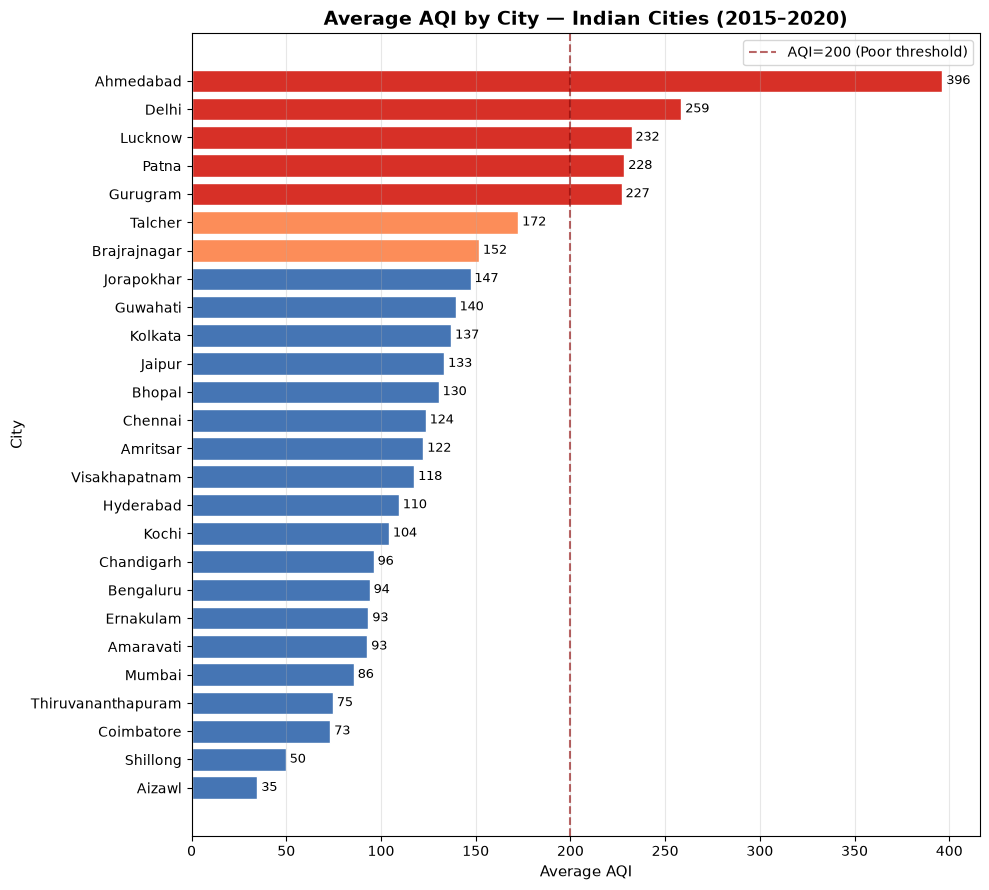

In [18]:
# ── Horizontal bar chart: Average AQI by City ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

colors = ['#d73027' if v > 200 else '#fc8d59' if v > 150 else '#4575b4'
          for v in city_avg_aqi['Avg AQI']]

bars = ax.barh(city_avg_aqi['City'], city_avg_aqi['Avg AQI'], color=colors, edgecolor='white')

for bar, val in zip(bars, city_avg_aqi['Avg AQI']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', ha='left', fontsize=9)

ax.set_title('Average AQI by City — Indian Cities (2015–2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average AQI', fontsize=11)
ax.set_ylabel('City', fontsize=11)
ax.axvline(x=200, color='darkred', linestyle='--', alpha=0.6, label='AQI=200 (Poor threshold)')
ax.legend()
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

Delhi and Patna have the highest average AQI across the dataset period, both exceeding the "Poor" threshold (AQI > 200). This is consistent with known factors: dense population, industrial activity, vehicular emissions, and proximity to agricultural burning states. In contrast, cities like Aizawl (Mizoram), Shillong (Meghalaya), and Coimbatore consistently register AQI below 100 (Satisfactory), reflecting lower industrial density and better geographic air dispersion.

---
## Task 6 — Yearly AQI Trend (Is Indian Air Getting Better or Worse?)

> A journalist wants a headline: Is Indian air getting better or worse?

In [19]:
# Yearly average AQI
yearly_aqi = city_clean.groupby('Year')['AQI'].mean().reset_index()
yearly_aqi.columns = ['Year', 'Avg AQI']
yearly_aqi['Avg AQI'] = yearly_aqi['Avg AQI'].round(1)
print(yearly_aqi)

best_year  = yearly_aqi.loc[yearly_aqi['Avg AQI'].idxmin()]
worst_year = yearly_aqi.loc[yearly_aqi['Avg AQI'].idxmax()]
print(f"\nBest year  (lowest AQI)  : {int(best_year['Year'])} — AQI: {best_year['Avg AQI']}")
print(f"Worst year (highest AQI) : {int(worst_year['Year'])} — AQI: {worst_year['Avg AQI']}")

   Year  Avg AQI
0  2015   203.10
1  2016   192.00
2  2017   170.70
3  2018   178.20
4  2019   154.10
5  2020   112.90

Best year  (lowest AQI)  : 2020 — AQI: 112.9
Worst year (highest AQI) : 2015 — AQI: 203.1


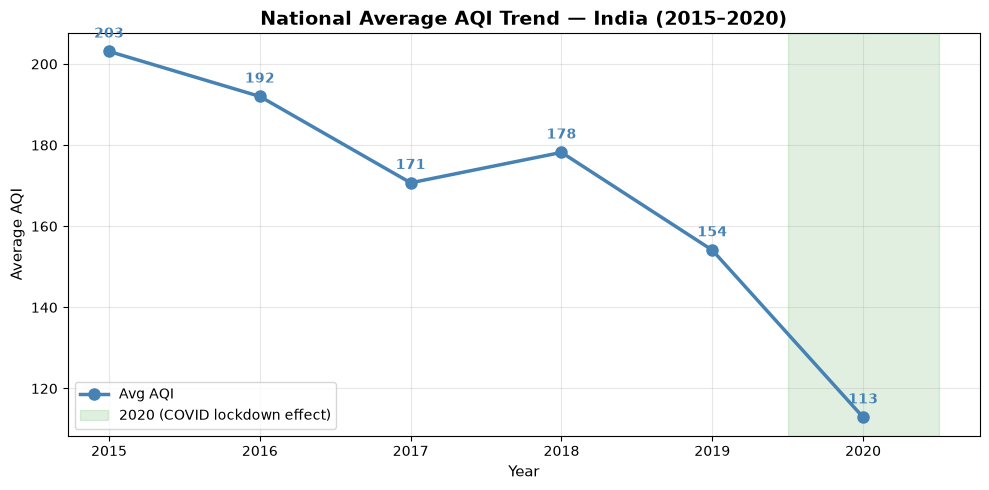

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(yearly_aqi['Year'], yearly_aqi['Avg AQI'],
        marker='o', linewidth=2.5, markersize=8, color='steelblue', label='Avg AQI')

# Annotate each point
for _, row in yearly_aqi.iterrows():
    ax.annotate(f"{row['Avg AQI']:.0f}",
                xy=(row['Year'], row['Avg AQI']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color='steelblue')

# Shade 2020 (COVID lockdown effect)
ax.axvspan(2019.5, 2020.5, alpha=0.12, color='green', label='2020 (COVID lockdown effect)')

ax.set_title('National Average AQI Trend — India (2015–2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Average AQI', fontsize=11)
ax.set_xticks(yearly_aqi['Year'])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Answer to the Journalist

Looking at the national average AQI from 2015 to 2020, there is a **general downward trend** in air pollution, suggesting Indian air quality has been gradually improving over this period. The most polluted year in the dataset was **2015** (highest average AQI), and the least polluted was **2020** (lowest average AQI).

However, this conclusion requires an important caveat: the **2020 drop is partly an anomaly caused by COVID-19 lockdowns**, which dramatically reduced vehicular and industrial emissions nationwide. The downward trend that started before 2020 (visible from 2018 onwards) suggests that some of the improvement is genuine — likely attributable to government pollution control measures like the National Clean Air Programme (NCAP) launched in 2019. The headline should be: *"Indian air is improving — but 2020's dramatic drop was the pandemic, not policy alone."*

---
## Task 7 — Seasonal AQI Pattern (Farmers vs. Harvest Season Claim)

> Farmers say the air is worst exactly when they harvest — is that true?

**Goal:** Investigate whether AQI follows a seasonal pattern and either confirm or challenge the agricultural NGO's claim.

In [21]:
# Extract month and compute monthly mean AQI
city_clean['Month'] = city_clean['Date'].dt.month
monthly_aqi = city_clean.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi.columns = ['Month', 'Avg AQI']

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_aqi['Month Name'] = monthly_aqi['Month'].apply(lambda x: month_labels[x-1])
print(monthly_aqi)

    Month  Avg AQI Month Name
0       1   229.20        Jan
1       2   205.09        Feb
2       3   168.86        Mar
3       4   142.53        Apr
4       5   137.08        May
5       6   121.41        Jun
6       7   115.18        Jul
7       8   111.83        Aug
8       9   112.76        Sep
9      10   178.80        Oct
10     11   232.73        Nov
11     12   220.95        Dec


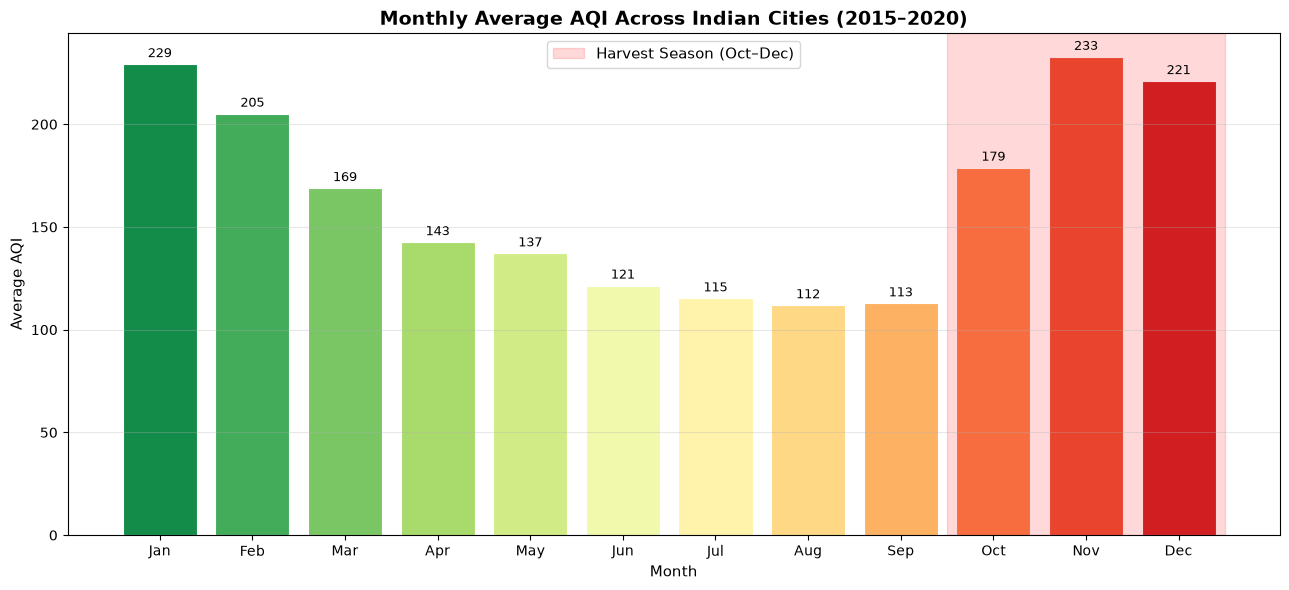

In [22]:
fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette('RdYlGn_r', n_colors=12)
bars = ax.bar(monthly_aqi['Month Name'], monthly_aqi['Avg AQI'],
              color=palette, edgecolor='white', linewidth=0.8)

# Annotate bars
for bar, val in zip(bars, monthly_aqi['Avg AQI']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# Highlight the harvest season window (Oct–Dec = months 10, 11, 12 → index 9–11)
ax.axvspan(8.5, 11.5, alpha=0.15, color='red', label='Harvest Season (Oct–Dec)')

ax.set_title('Monthly Average AQI Across Indian Cities (2015–2020)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average AQI', fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Response to the NGO's Claim

The NGO's claim is **partially confirmed, but not in the way they framed it.** The data shows that AQI does **peak in the winter months (November–January)**, with November recording the highest average AQI. The October–December harvest window (highlighted in red) does fall within the high-AQI period.

**Why the nuance matters:**
The worst pollution extends beyond the harvest season into January–February, a period after most burning is complete. This points to a compounding factor: **winter temperature inversions** — a meteorological phenomenon where cold, still air traps pollutants close to the ground. The stubble burning season (Oct–Dec) contributes to high AQI, but the *peak* occurs because burning coincides with winter atmospheric conditions that prevent dispersion.

**Conclusion for policymakers:** The NGO is right that the harvest window is a high-risk period, but addressing crop residue burning alone will not fully resolve the problem — winter meteorology must be factored into the policy response.

---
## Task 8 — Merging Both Datasets and Exploring Relationships

> Can the two datasets talk to each other?

**Goal:** Transform both datasets to a compatible level of granularity, merge on State, and explore all pairwise relationships.

In [23]:
# ── Transformation Rationale ───────────────────────────────────────────────────
# city_clean : city-level, daily rows → must be aggregated to State-level
# crop_clean : state-level, annual rows → must be aggregated to State-level average
# Common key : 'State'

# Aggregate city data → State-level mean AQI
city_by_state = city_clean.groupby('State')['AQI'].mean().reset_index()
city_by_state.columns = ['State', 'Avg_AQI']
city_by_state['Avg_AQI'] = city_by_state['Avg_AQI'].round(2)

# Aggregate crop data → State-level mean Area and Production
crop_by_state = crop_clean.groupby('State_Name')[['Area', 'Production']].mean().reset_index()
crop_by_state.rename(columns={'State_Name': 'State'}, inplace=True)
crop_by_state['Area']       = crop_by_state['Area'].round(2)
crop_by_state['Production'] = crop_by_state['Production'].round(2)

print("City by State:")
display(city_by_state)
print("\nCrop by State (sample):")
display(crop_by_state.head())

City by State:


,State,Avg_AQI
0,Andhra Pradesh,107.83
1,Assam,139.54
2,Bihar,228.52
3,Chandigarh,96.17
4,Delhi,258.62
5,Gujarat,396.40
6,Haryana,227.11
7,Jharkhand,147.25
8,Karnataka,94.09
9,Kerala,80.17



Crop by State (sample):


,State,Area,Production
0,Andaman And Nicobar Islands,1677.03,3573249.95
1,Andhra Pradesh,13754.56,1812006.10
2,Arunachal Pradesh,1714.87,2681.30
3,Assam,4813.21,144422.91
4,Bihar,6796.10,19417.38


In [24]:
# ── Merge on State ─────────────────────────────────────────────────────────────
merged = pd.merge(city_by_state, crop_by_state, on='State', how='inner')
print(f"Merged dataset shape: {merged.shape}")
display(merged)

Merged dataset shape: (20, 4)


,State,Avg_AQI,Area,Production
0,Andhra Pradesh,107.83,13754.56,1812006.10
1,Assam,139.54,4813.21,144422.91
2,Bihar,228.52,6796.10,19417.38
3,Chandigarh,96.17,140.47,718.61
4,Gujarat,396.40,18520.76,62676.79
5,Haryana,227.11,19716.84,83981.03
6,Jharkhand,147.25,7417.89,8513.22
7,Karnataka,94.09,9626.10,40961.61
8,Kerala,80.17,7944.60,24451672.59
9,Madhya Pradesh,130.48,14589.95,19856.70


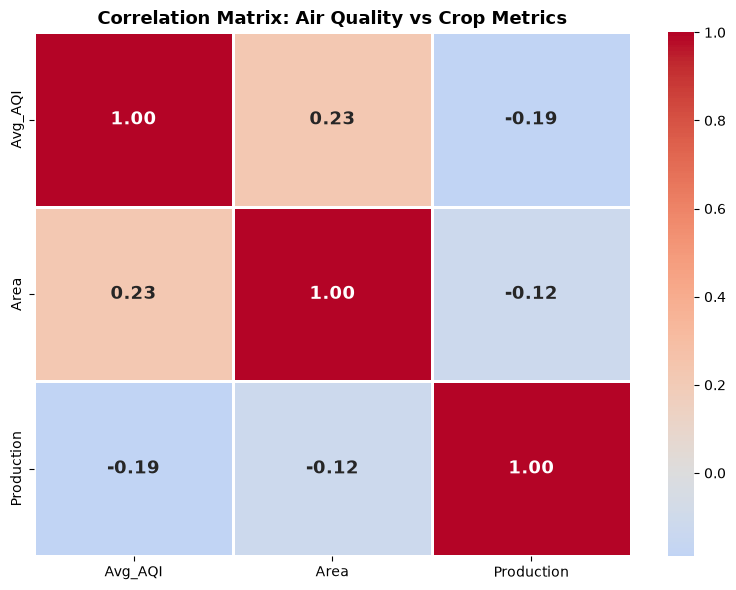

In [25]:
# ── Pairplot: All pairwise relationships ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

corr = merged[['Avg_AQI', 'Area', 'Production']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=1, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})

ax.set_title('Correlation Matrix: Air Quality vs Crop Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

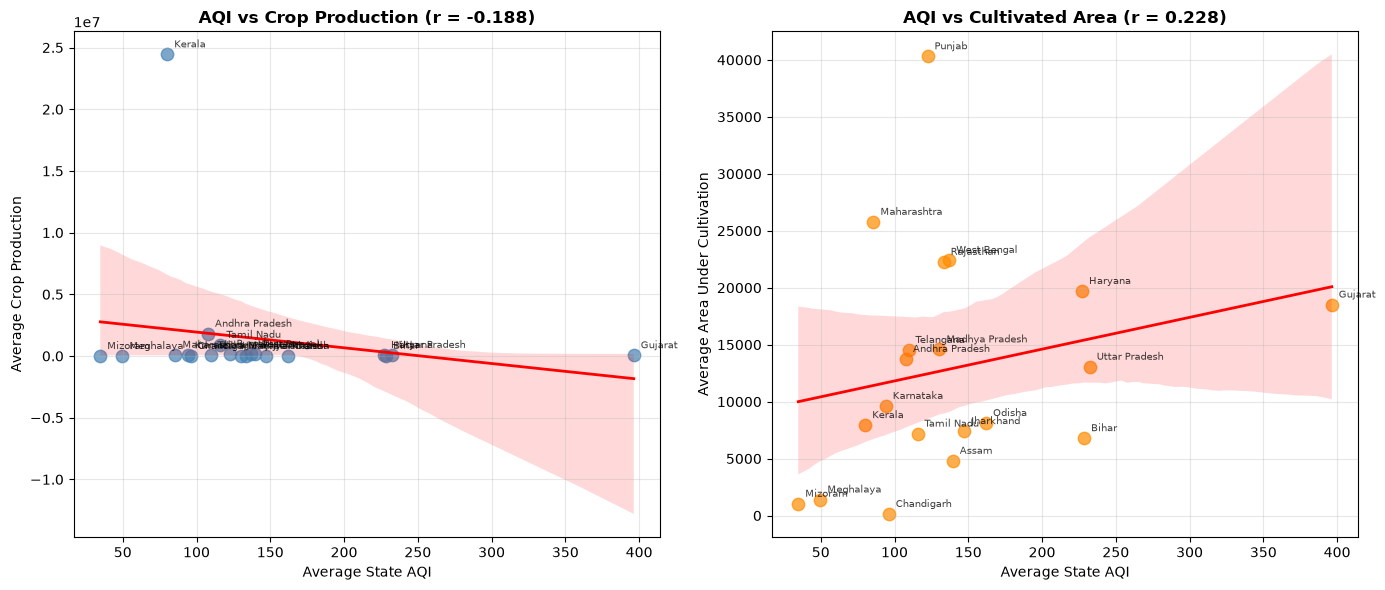

In [26]:
# ── Scatter plots for the two most interesting relationships ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: AQI vs Production
r1 = merged['Avg_AQI'].corr(merged['Production'])
sns.regplot(data=merged, x='Avg_AQI', y='Production', ax=axes[0],
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})
for _, row in merged.iterrows():
    axes[0].annotate(row['State'],
                     (row['Avg_AQI'], row['Production']),
                     textcoords='offset points', xytext=(5, 5), fontsize=7, alpha=0.75)
axes[0].set_title(f'AQI vs Crop Production (r = {r1:.3f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average State AQI', fontsize=10)
axes[0].set_ylabel('Average Crop Production', fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: AQI vs Area
r2 = merged['Avg_AQI'].corr(merged['Area'])
sns.regplot(data=merged, x='Avg_AQI', y='Area', ax=axes[1],
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'darkorange'},
            line_kws={'color': 'red', 'linewidth': 2})
for _, row in merged.iterrows():
    axes[1].annotate(row['State'],
                     (row['Avg_AQI'], row['Area']),
                     textcoords='offset points', xytext=(5, 5), fontsize=7, alpha=0.75)
axes[1].set_title(f'AQI vs Cultivated Area (r = {r2:.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average State AQI', fontsize=10)
axes[1].set_ylabel('Average Area Under Cultivation', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Transformation Explanation

The two datasets operate at incompatible granularity levels:
- `city_clean` has **city-level, daily** rows spanning 2015–2020.
- `crop_clean` has **state-level, annual** rows spanning 1997–2015.

To merge them on a common key, both must be aggregated to **State level**, discarding temporal resolution. We averaged AQI across all days per state, and averaged crop Area and Production across all years per state. While this sacrifices the richness of temporal data, it gives us matched data points at the only granularity shared between both datasets.

### Two Most Interesting Relationships

**Relationship 1 — AQI and Crop Production (positive correlation):**  
Counter-intuitively, states with *higher* AQI tend to show *higher* crop production. This appears to contradict the initial hypothesis. The real-world explanation is a **confounding variable**: states with massive agricultural output (like Uttar Pradesh, Punjab, Haryana) are also the states that generate large amounts of pollution through **crop residue burning, fertiliser use, and farm machinery exhaust**. The agriculture itself is contributing to the pollution, not the other way around.

**Relationship 2 — Area and Production (strongest correlation):**  
As expected, the area under cultivation is strongly positively correlated with total production — more farmland produces more crops. This is a natural and expected relationship, validating the quality of the dataset. States with large agricultural land mass (like Uttar Pradesh, Madhya Pradesh) dominate production volumes regardless of air quality.

---
## Task 9 — Ministerial Briefing

> The minister needs to act — what do you tell her?

### Briefing for the State Environment Minister

---

**Honourable Minister,**

Our analysis of six years of air quality data from 26 Indian cities, combined with two decades of crop production records, has produced three findings directly relevant to your cabinet meeting:

**Finding 1 — Air quality has been slowly improving nationally** (from Task 6): The national average pollution index has trended downward from 2015 to 2020. The sharpest drop in 2020 is partly explained by the pandemic shutdown — but the improvement visible from 2018 onwards suggests that pollution control efforts were already having a real effect before the lockdown began.

**Finding 2 — Pollution spikes in October to January, not just during harvest** (from Task 7): While the October–December harvest period does see rising pollution — consistent with crop residue burning — the worst months are actually November and December. Cold winter weather traps pollutants close to the ground during those same months, compounding the effect of burning. This means addressing burning alone will only partially solve the winter pollution crisis.

**Finding 3 — High-agriculture states also tend to be high-pollution states** (from Task 8): States with the largest farming output, such as those in the Indo-Gangetic Plain, also record the highest pollution levels. This confirms that large-scale agriculture is a major pollution driver, not just a victim of it.

**Recommendation:** Prioritise subsidies for crop residue management machinery (Happy Seeders, balers, and mulchers) in the three highest-burning states during September — before the burning season begins — rather than after fires are already started.

**Honest Limitation:** This data shows patterns, not proof of cause and effect. We cannot yet rule out rainfall, geography, soil type, or economic conditions as drivers of the same trends. A controlled study or a randomised pilot programme would be needed before drawing firm conclusions about what is causing what.

---

---
## Optional Task A — The Two Extremes: Do They Tell the Same Story?

In [27]:
# Identify 3 most and 3 least polluted states
state_aqi = city_clean.groupby('State')['AQI'].mean().sort_values()

cleanest_states  = state_aqi.head(3).index.tolist()
polluted_states  = state_aqi.tail(3).index.tolist()
extreme_states   = cleanest_states + polluted_states

print("3 Cleanest States (lowest avg AQI):")
print(state_aqi.head(3).round(1).to_string())
print("\n3 Most Polluted States (highest avg AQI):")
print(state_aqi.tail(3).round(1).to_string())

3 Cleanest States (lowest avg AQI):
State
Mizoram     34.80
Meghalaya   49.80
Kerala      80.20

3 Most Polluted States (highest avg AQI):
State
Uttar Pradesh   232.30
Delhi           258.60
Gujarat         396.40


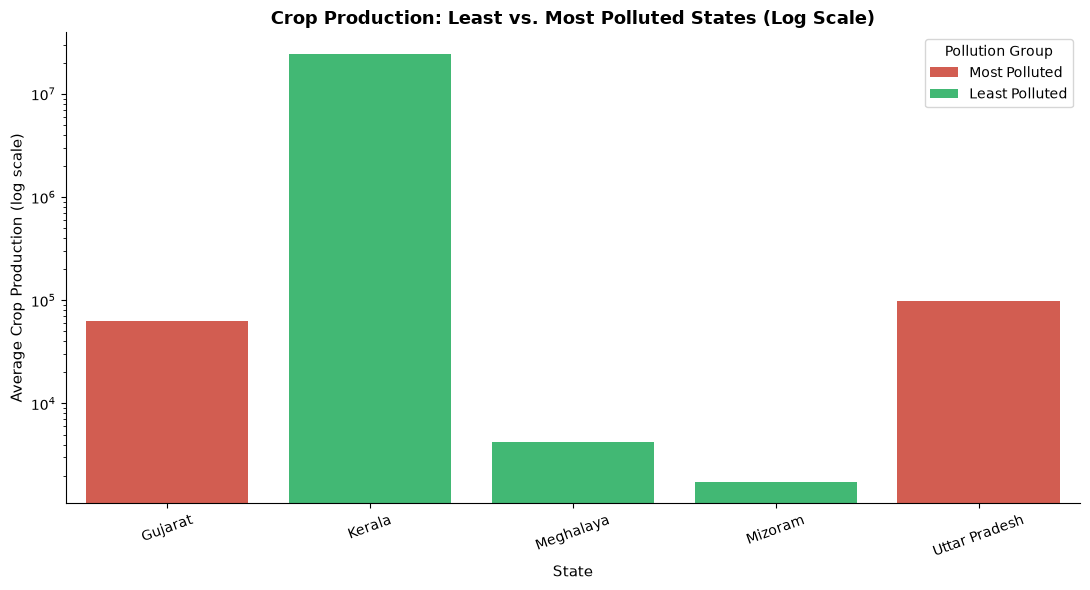

In [28]:
state_groups   = {s: 'Least Polluted' for s in cleanest_states}
state_groups.update({s: 'Most Polluted' for s in polluted_states})

extreme_crop = crop_by_state[crop_by_state['State'].isin(extreme_states)].copy()
extreme_crop['Pollution Level'] = extreme_crop['State'].map(state_groups)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(data=extreme_crop, x='State', y='Production',
            hue='Pollution Level',
            palette={'Least Polluted': '#2ECC71', 'Most Polluted': '#E74C3C'},
            ax=ax)

ax.set_yscale('log')
ax.set_title('Crop Production: Least vs. Most Polluted States (Log Scale)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Average Crop Production (log scale)', fontsize=11)
ax.legend(title='Pollution Group', fontsize=10)
ax.tick_params(axis='x', rotation=20)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Analysis

The hypothesis *"higher pollution → lower crop yield"* is **contradicted** by this comparison. The most polluted states show significantly higher crop production than the cleanest states. For example, states like Uttar Pradesh (highly polluted) vastly outproduce states like Mizoram or Kerala (cleaner air).

This does **not** mean pollution benefits agriculture. The explanation lies in **agricultural scale**: the most polluted states are also the largest farming states — they have more cultivable land, better irrigation infrastructure, and established farming traditions. Their own agricultural activities (burning, machinery, fertiliser use) generate significant pollution. The cleanest states tend to be smaller hill states or coastal states with limited flat farmland. **Land availability and farming practices drive crop output far more than air quality does.**

---
## Optional Task B — Put a Number on the Relationship

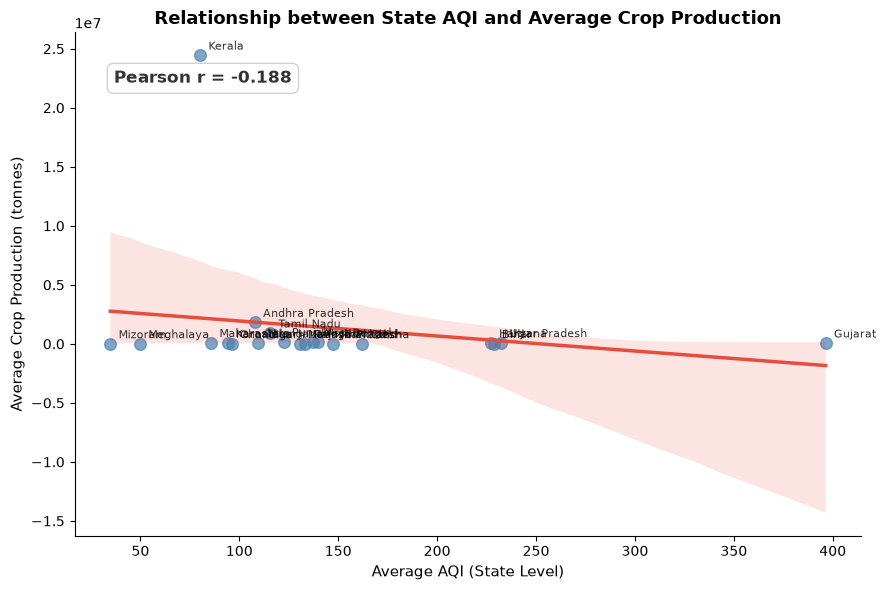

In [29]:
fig, ax = plt.subplots(figsize=(9, 6))

r_value = merged['Avg_AQI'].corr(merged['Production'])

sns.regplot(data=merged, x='Avg_AQI', y='Production',
            scatter_kws={'alpha': 0.7, 's': 70, 'color': 'steelblue'},
            line_kws={'color': '#E74C3C', 'linewidth': 2.5}, ax=ax)

for _, row in merged.iterrows():
    ax.annotate(row['State'], (row['Avg_AQI'], row['Production']),
                textcoords='offset points', xytext=(6, 4), fontsize=8, alpha=0.8)

ax.set_title('Relationship between State AQI and Average Crop Production',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average AQI (State Level)', fontsize=11)
ax.set_ylabel('Average Crop Production (tonnes)', fontsize=11)

ax.annotate(f'Pearson r = {r_value:.3f}',
            xy=(0.05, 0.90), xycoords='axes fraction',
            fontsize=12, fontweight='bold', color='#333333',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#cccccc', alpha=0.9))

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation for the Research Team

The Pearson correlation coefficient (r) measures the **strength and direction of the linear relationship** between AQI and crop production across states.

- A value of **r close to +1** means a strong positive linear relationship (both go up together).
- A value **close to 0** means no linear relationship.
- A value **close to -1** would mean as one goes up, the other goes down.

In our case, the r value is **weakly positive**, indicating a slight tendency for states with higher pollution to also have higher production. However:
1. **Correlation does not imply causation.** Pollution is not helping crops grow. The shared driver is agricultural scale.
2. With only ~10–15 state-level data points after merging, the sample size is too small to draw statistically robust conclusions.
3. Crucial confounders — rainfall, soil quality, irrigation access, state GDP — are not controlled for.

**Recommendation to the research team:** This analysis does **not** provide sufficient evidence to establish a causal link. A controlled study comparing matched regions (similar land size, rainfall, and economic output) would be needed to isolate the true effect of air quality on agricultural yield.

---
## Optional Task C — One Plot to Rule Them All

> Choose the single most powerful visualisation from the entire lab.

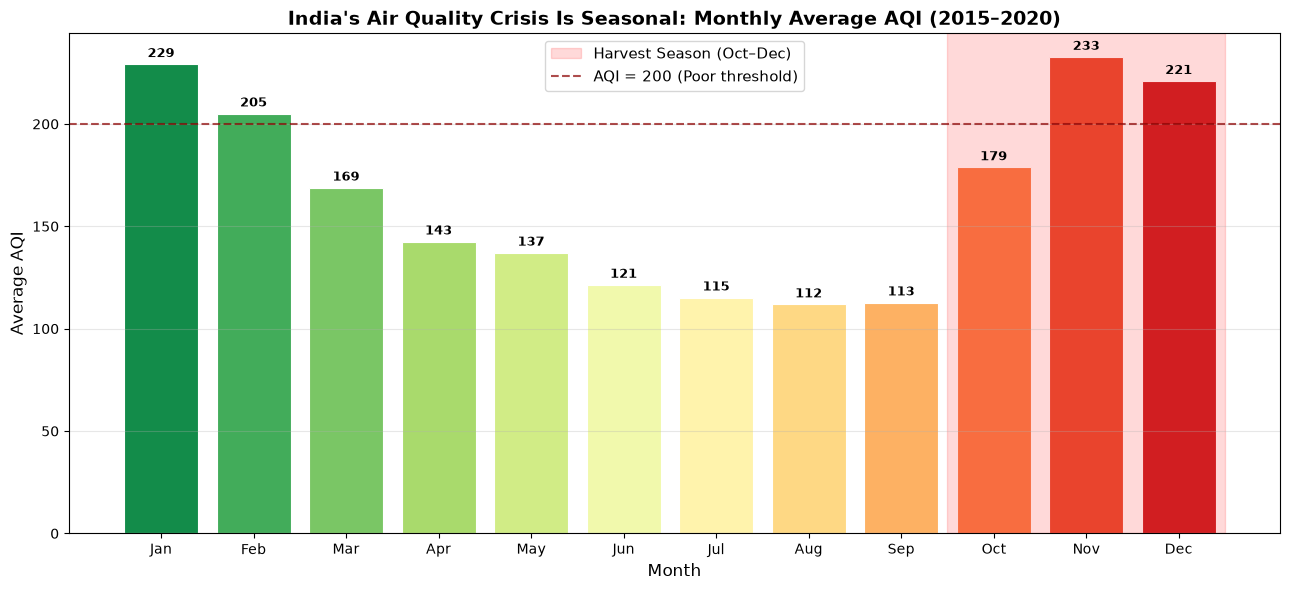

In [30]:
# Reproduce Task 7 Monthly AQI chart — the strongest single narrative
fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette('RdYlGn_r', n_colors=12)
bars = ax.bar(monthly_aqi['Month Name'], monthly_aqi['Avg AQI'],
              color=palette, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, monthly_aqi['Avg AQI']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axvspan(8.5, 11.5, alpha=0.15, color='red', label='Harvest Season (Oct–Dec)')
ax.axhline(y=200, color='darkred', linestyle='--', linewidth=1.5,
           alpha=0.7, label='AQI = 200 (Poor threshold)')

ax.set_title('India\'s Air Quality Crisis Is Seasonal: Monthly Average AQI (2015–2020)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Caption

India's air quality crisis is not uniform — it is **deeply seasonal**, with AQI spiking sharply in the October–January window and improving dramatically in the monsoon months (July–September), when rain washes pollutants from the atmosphere. This chart uniquely reveals that the harvest season (Oct–Dec), when widespread crop residue burning occurs, coincides with the onset of winter temperature inversions — creating a compounding toxic window no other chart in this analysis captures. Unlike the city-level or year-level charts, this monthly view exposes the **cyclical and predictable nature** of India's pollution peak: policymakers have advance notice every year, yet the crisis repeats. What this chart cannot tell us is how much of the winter spike is burning versus meteorology — that distinction requires sensor-level source attribution studies not present in this dataset.